# 09_inference_router_analysis.ipynb

Inference + analysis notebook for the **VLM Router**.

This notebook:

- Loads the **trained router checkpoint**.
- Loads the **router_*_trainer.parquet** files (with `image_png` and text).
- Runs **inference** on the test set.
- Plots:
  - Overall test accuracy
  - Confusion matrix
  - Per-task accuracy
  - Per-model usage & accuracy
  - Simple **ablations**:
    - Full multimodal (image + text)
    - Text-only (image zeroed out)
    - Image-only (text removed)
- Shows **qualitative examples** for correct / incorrect routing decisions.

> Assumes you already ran the training notebook (`08_training_router_with_images.ipynb`) and saved a checkpoint.

In [1]:
import os
import io
from dataclasses import dataclass
from pathlib import Path
from typing import List, Optional

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    CLIPImageProcessor,
    CLIPVisionModel,
)

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Imports done. Torch version:", torch.__version__)

/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Imports done. Torch version: 2.9.1+cu128


In [2]:
# ---- Config ----
@dataclass
class InferenceConfig:
    # Paths
    project_root: Path = Path.cwd().parent  # adjust if needed
    data_root: Path = Path.cwd().parent.parent.parent / "dataset" / "final_dataset" 
    router_subdir: str = "router_lexico"  # where 07_build_train_datasets wrote trainer files
    test_file: str = "router_test_trainer.parquet"

    # Checkpoint path (update this to your actual checkpoint)
    checkpoint_path: Path = Path.cwd() / "router_checkpoints" / "router_best.pt"

    # Model names (must match training)
    vision_encoder_name: str = "openai/clip-vit-base-patch32"
    text_encoder_name: str   = "distilbert-base-uncased"
    text_tokenizer_name: str = "distilbert-base-uncased"

    use_image: bool = True
    freeze_vision: bool = True
    freeze_text_encoder: bool = False

    max_text_length: int = 256
    eval_batch_size: int = 32
    num_workers: int = 4

    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42


config = InferenceConfig()

def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.seed)

print(config)
print("Using device:", config.device)

InferenceConfig(project_root=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm'), data_root=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset'), router_subdir='router_lexico', test_file='router_test_trainer.parquet', checkpoint_path=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_checkpoints/router_best.pt'), vision_encoder_name='openai/clip-vit-base-patch32', text_encoder_name='distilbert-base-uncased', text_tokenizer_name='distilbert-base-uncased', use_image=True, freeze_vision=True, freeze_text_encoder=False, max_text_length=256, eval_batch_size=32, num_workers=4, device='cuda', seed=42)
Using device: cuda


In [3]:
# ---- Load test parquet ----
router_dir = config.data_root / config.router_subdir
test_path = router_dir / config.test_file

print("Router data dir:", router_dir)
print("Test path:", test_path)

test_df = pd.read_parquet(test_path)

print("test_df shape:", test_df.shape)
print("Columns (first 40):")
print(test_df.columns[:40])

display(test_df.head())

# Utility metadata (for context)
if "utility_scheme" in test_df.columns:
    DATA_UTILITY_SCHEME = str(test_df["utility_scheme"].iloc[0])
else:
    DATA_UTILITY_SCHEME = "unknown"

HIER_W_SAMPLE = float(test_df.get("hier_w_sample", pd.Series([np.nan])).iloc[0])
HIER_W_TASK   = float(test_df.get("hier_w_task",   pd.Series([np.nan])).iloc[0])
HIER_W_GLOBAL = float(test_df.get("hier_w_global", pd.Series([np.nan])).iloc[0])

print("\nUtility metadata:")
print("  utility_scheme:", DATA_UTILITY_SCHEME)
print("  hier_w_sample :", HIER_W_SAMPLE)
print("  hier_w_task   :", HIER_W_TASK)
print("  hier_w_global :", HIER_W_GLOBAL)

Router data dir: /storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset/router_lexico
Test path: /storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset/router_lexico/router_test_trainer.parquet
test_df shape: (13707, 33)
Columns (first 40):
Index(['sample_id', 'image_path', 'image_bytes_hash', 'prompt_raw',
       'img_width', 'img_height', 'img_aspect_ratio',
       'txt_prompt_length_chars', 'txt_prompt_length_words', 'router_task',
       'source_dataset', 'source_config', 'txt_question_type',
       'txt_has_mc_options', 'ground_truth', 'ground_truth_type',
       'router_best_model_id', 'router_best_model_name', 'router_chosen_perf',
       'router_chosen_cost', 'image_png', 'input_text', 'label_id',
       'label_name', 'utility_scheme', 'hier_w_sample', 'hier_w_task',
       'hier_w_global', 'router_soft_p_deepseek_ocr',
       'router_soft_p_qwen2_5_vl_3b', 'router_soft_p_qwen2_5_vl_7b',
       'router_soft_p_qwen3_vl_8b_thinking', 'router_soft_p_g

,sample_id,image_path,image_bytes_hash,prompt_raw,img_width,img_height,img_aspect_ratio,txt_prompt_length_chars,txt_prompt_length_words,router_task,...,label_name,utility_scheme,hier_w_sample,hier_w_task,hier_w_global,router_soft_p_deepseek_ocr,router_soft_p_qwen2_5_vl_3b,router_soft_p_qwen2_5_vl_7b,router_soft_p_qwen3_vl_8b_thinking,router_soft_p_gemma_3_27b
0,ai2d_00004_bf3d9c5fd30bf304,None,bf3d9c5fd30bf304,Question: If the Termites in the community bel...,1100.0,532.0,2.068,211.0,34.0,diagram_reasoning,...,qwen2_5_vl_7b,lexico_d0.02,0.6,0.35,0.05,0.0,0.090545,0.909455,0.0,0.0
1,ai2d_00007_e6f58451a22503d1,None,e6f58451a22503d1,Question: what does the 2nd picture show?\nCho...,1500.0,1344.0,1.116,162.0,27.0,diagram_reasoning,...,qwen2_5_vl_7b,lexico_d0.02,0.6,0.35,0.05,0.0,0.090595,0.909405,0.0,0.0
2,ai2d_00019_e5f934cfc0951972,None,e5f934cfc0951972,Question: A food web for a ecosystem is shown ...,305.0,297.0,1.027,223.0,40.0,diagram_reasoning,...,gemma_3_27b,lexico_d0.02,0.6,0.35,0.05,0.0,0.000000,0.000000,0.0,1.0
3,ai2d_00021_59cfa73bc8485386,None,59cfa73bc8485386,Question: What is the lowermost section of a v...,1402.0,891.0,1.574,166.0,27.0,diagram_reasoning,...,qwen2_5_vl_7b,lexico_d0.02,0.6,0.35,0.05,0.0,0.090568,0.909432,0.0,0.0
4,ai2d_00023_bd686a44c25987c8,None,bd686a44c25987c8,Question: What is the insulating envelope of m...,549.0,284.0,1.933,229.0,39.0,diagram_reasoning,...,qwen2_5_vl_7b,lexico_d0.02,0.6,0.35,0.05,0.0,0.090530,0.909470,0.0,0.0



Utility metadata:
  utility_scheme: lexico_d0.02
  hier_w_sample : 0.6
  hier_w_task   : 0.35
  hier_w_global : 0.05


Random sample index: 10476
sample_id: tabmwp_01794_931a767278fd6040
router_task: table_math
router_best_model_id: 1
router_best_model_name: qwen2_5_vl_3b

Prompt:
Look at the following schedule. When does the track meet end?


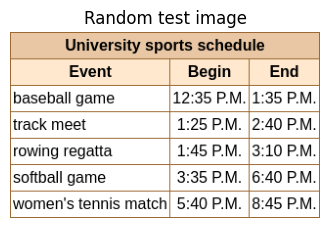

In [4]:
# ---- Visual sanity check: show one random test sample ----
import random

rand_idx = random.randint(0, len(test_df) - 1)
row = test_df.iloc[rand_idx]

print("Random sample index:", rand_idx)
print("sample_id:", row.get("sample_id"))
print("router_task:", row.get("router_task"))
print("router_best_model_id:", row.get("router_best_model_id"))
print("router_best_model_name:", row.get("router_best_model_name"))
print("\nPrompt:")
print(row.get("prompt_raw"))

if "image_png" in row and isinstance(row["image_png"], (bytes, bytearray, memoryview)):
    img = Image.open(io.BytesIO(row["image_png"])).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Random test image")
    plt.show()
else:
    print("No image_png bytes found for this sample.")

In [5]:
# ---- RouterDataset (inference) ----
class RouterDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        image_processor: CLIPImageProcessor,
        tokenizer,
        config: InferenceConfig,
        model_names: List[str],
    ):
        self.df = df.reset_index(drop=True)
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.config = config
        self.model_names = model_names

    def __len__(self):
        return len(self.df)

    def _load_image(self, row) -> torch.Tensor:
        # Prefer image_png bytes
        if "image_png" in row.index:
            img_bytes = row["image_png"]
            if isinstance(img_bytes, (bytes, bytearray, memoryview)):
                try:
                    pil_img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                    inputs = self.image_processor(images=pil_img, return_tensors="pt")
                    pixel_values = inputs["pixel_values"].squeeze(0)
                    return pixel_values
                except Exception as e:
                    print(f"[WARN] Failed to decode image_png for sample_id={row.get('sample_id', 'NA')}: {e}")

        # Fallback: black image
        return torch.zeros(3, 224, 224)

    def _build_router_text(self, row) -> str:
        prompt = row.get("prompt_raw", "")

        w = row.get("img_width", None)
        h = row.get("img_height", None)
        ar = row.get("img_aspect_ratio", None)
        len_chars = row.get("txt_prompt_length_chars", None)
        len_words = row.get("txt_prompt_length_words", None)

        meta_parts = []
        if len_words is not None and not np.isnan(len_words):
            meta_parts.append(f"PromptLenWords: {int(len_words)}.")
        if len_chars is not None and not np.isnan(len_chars):
            meta_parts.append(f"PromptLenChars: {int(len_chars)}.")
        if w is not None and h is not None and not np.isnan(w) and not np.isnan(h):
            meta_parts.append(f"ImageWidth: {int(w)}. ImageHeight: {int(h)}.")
        if ar is not None and not np.isnan(ar):
            meta_parts.append(f"ImageAR: {float(ar):.2f}.")

        meta_str = " ".join(meta_parts)
        router_text = f"{meta_str} Question: {prompt}"
        return router_text

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        if self.config.use_image:
            pixel_values = self._load_image(row)
        else:
            pixel_values = torch.zeros(3, 224, 224)
        pixel_values = pixel_values.float()

        # Text
        router_text = self._build_router_text(row)
        encoding = self.tokenizer(
            router_text,
            padding="max_length",
            truncation=True,
            max_length=self.config.max_text_length,
            return_tensors="pt",
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        label = int(row["router_best_model_id"])  # ground-truth best model

        return {
            "pixel_values": pixel_values,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "label": label,
            "sample_id": row.get("sample_id"),
            "router_task": row.get("router_task"),
        }

In [6]:
# ---- Tokenizer, processor, dataset, dataloader ----
# Infer model_names from router_best_model_name mapping
if "router_best_model_id" in test_df.columns and "router_best_model_name" in test_df.columns:
    uniq = (
        test_df[["router_best_model_id", "router_best_model_name"]]
        .drop_duplicates()
        .sort_values("router_best_model_id")
    )
    model_names = uniq["router_best_model_name"].tolist()
else:
    raise ValueError("router_best_model_id / router_best_model_name not found in test_df.")

num_models = len(model_names)
print("Model names:", model_names)
print("Number of models:", num_models)

image_processor = CLIPImageProcessor.from_pretrained(config.vision_encoder_name)
tokenizer = AutoTokenizer.from_pretrained(config.text_tokenizer_name)

test_dataset = RouterDataset(test_df, image_processor, tokenizer, config, model_names)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.eval_batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=True,
)

print("Test DataLoader ready.")

Model names: ['deepseek_ocr', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking', 'gemma_3_27b']
Number of models: 5
Test DataLoader ready.


In [ ]:
# ---- Multimodal Router Model (must match training) ----
class MultimodalRouterModel(nn.Module):
    def __init__(
        self,
        config: InferenceConfig,
        num_models: int,
        model_names: List[str],
    ):
        super().__init__()
        self.config = config
        self.num_models = num_models
        self.model_names = model_names

        # Vision encoder (CLIP)
        self.vision = CLIPVisionModel.from_pretrained(config.vision_encoder_name)
        vision_hidden_size = self.vision.config.hidden_size

        # Text encoder
        self.text_encoder = AutoModel.from_pretrained(config.text_encoder_name)
        text_hidden_size = self.text_encoder.config.hidden_size

        hidden_dim = max(vision_hidden_size, text_hidden_size)
        self.vision_proj = nn.Linear(vision_hidden_size, hidden_dim)
        self.text_proj   = nn.Linear(text_hidden_size, hidden_dim)

        fused_dim = hidden_dim * 2
        self.fusion_mlp = nn.Sequential(
            nn.Linear(fused_dim, fused_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(fused_dim, hidden_dim),
            nn.ReLU(),
        )

        self.classifier = nn.Linear(hidden_dim, num_models)

        if config.freeze_vision:
            for p in self.vision.parameters():
                p.requires_grad = False

        if config.freeze_text_encoder:
            for p in self.text_encoder.parameters():
                p.requires_grad = False

    def forward(self, pixel_values, input_ids, attention_mask):
        vision_outputs = self.vision(pixel_values=pixel_values)
        vision_emb = vision_outputs.pooler_output
        vision_emb = self.vision_proj(vision_emb)

        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        if hasattr(text_outputs, "pooler_output") and text_outputs.pooler_output is not None:
            text_emb = text_outputs.pooler_output
        else:
            last_hidden = text_outputs.last_hidden_state
            mask = attention_mask.unsqueeze(-1).float()
            text_emb = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        text_emb = self.text_proj(text_emb)

        fused = torch.cat([vision_emb, text_emb], dim=-1)
        fused = self.fusion_mlp(fused)

        logits = self.classifier(fused)
        return logits

In [11]:
# ---- Instantiate model & load checkpoint ----
model = MultimodalRouterModel(config, num_models=num_models, model_names=model_names)
model = model.to(config.device)

if config.checkpoint_path.exists():
    print("Loading checkpoint from:", config.checkpoint_path)
    state = torch.load(config.checkpoint_path, map_location=config.device, weights_only=False)
    # state can be either full state dict or {"model_state_dict": ...}
    if isinstance(state, dict) and "state_dict" in state:
        model.load_state_dict(state["state_dict"])
    elif isinstance(state, dict) and "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
    else:
        model.load_state_dict(state)
    print("Checkpoint loaded.")
else:
    print("WARNING: checkpoint not found at", config.checkpoint_path)
    print("Using randomly initialized weights (for debugging only).")

Loading checkpoint from: /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_checkpoints/router_best.pt


RuntimeError: Error(s) in loading state_dict for MultimodalRouterModel:
	Missing key(s) in state_dict: "vision.vision_model.embeddings.class_embedding", "vision.vision_model.embeddings.patch_embedding.weight", "vision.vision_model.embeddings.position_embedding.weight", "vision.vision_model.pre_layrnorm.weight", "vision.vision_model.pre_layrnorm.bias", "vision.vision_model.encoder.layers.0.self_attn.k_proj.weight", "vision.vision_model.encoder.layers.0.self_attn.k_proj.bias", "vision.vision_model.encoder.layers.0.self_attn.v_proj.weight", "vision.vision_model.encoder.layers.0.self_attn.v_proj.bias", "vision.vision_model.encoder.layers.0.self_attn.q_proj.weight", "vision.vision_model.encoder.layers.0.self_attn.q_proj.bias", "vision.vision_model.encoder.layers.0.self_attn.out_proj.weight", "vision.vision_model.encoder.layers.0.self_attn.out_proj.bias", "vision.vision_model.encoder.layers.0.layer_norm1.weight", "vision.vision_model.encoder.layers.0.layer_norm1.bias", "vision.vision_model.e

In [ ]:
# ---- Inference helpers ----
@torch.no_grad()
def run_inference(
    model,
    loader,
    config: InferenceConfig,
    mode: str = "full",  # "full", "text_only", "image_only"
):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    all_sample_ids = []
    all_tasks = []

    for batch in loader:
        pixel_values = batch["pixel_values"].to(config.device)
        input_ids = batch["input_ids"].to(config.device)
        attention_mask = batch["attention_mask"].to(config.device)
        labels = batch["label"].to(config.device)

        # Ablations
        if mode == "text_only":
            pixel_values = torch.zeros_like(pixel_values)
        elif mode == "image_only":
            pad_id = tokenizer.pad_token_id or 0
            input_ids = torch.full_like(input_ids, pad_id)
            attention_mask = torch.zeros_like(attention_mask)

        logits = model(pixel_values, input_ids, attention_mask)
        probs = torch.softmax(logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_sample_ids.extend(batch["sample_id"])
        all_tasks.extend(batch["router_task"])

    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    acc = (all_labels == all_preds).mean()

    results = pd.DataFrame({
        "sample_id": all_sample_ids,
        "router_task": all_tasks,
        "label_id": all_labels,
        "pred_id": all_preds,
        "mode": mode,
    })

    return acc, results, all_probs

In [ ]:
# ---- Run inference for full, text-only, image-only ----
full_acc, full_results, full_probs = run_inference(model, test_loader, config, mode="full")
text_acc, text_results, text_probs = run_inference(model, test_loader, config, mode="text_only")
img_acc, img_results, img_probs   = run_inference(model, test_loader, config, mode="image_only")

print(f"Full (image+text) accuracy : {full_acc:.4f}")
print(f"Text-only accuracy        : {text_acc:.4f}")
print(f"Image-only accuracy       : {img_acc:.4f}")

all_results = pd.concat([full_results, text_results, img_results], ignore_index=True)
display(all_results.head())

In [ ]:
# ---- Confusion matrix (full model) ----
labels = list(range(num_models))
cm = confusion_matrix(full_results["label_id"], full_results["pred_id"], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_names)

plt.figure(figsize=(8, 8))
disp.plot(include_values=True, xticks_rotation="vertical", cmap="Blues")
plt.title("Router confusion matrix (test set, full image+text)")
plt.tight_layout()
plt.show()

In [ ]:
# ---- Per-task accuracy ----
task_group = full_results.groupby("router_task")
task_acc = task_group.apply(lambda g: (g["label_id"] == g["pred_id"]).mean()).sort_values(ascending=False)
task_counts = task_group.size()

task_acc_df = pd.DataFrame({
    "router_task": task_acc.index,
    "accuracy": task_acc.values,
    "count": task_counts.values,
})

print("Per-task accuracy:")
display(task_acc_df)

plt.figure(figsize=(10, 5))
plt.bar(task_acc_df["router_task"], task_acc_df["accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Per-task router accuracy (full image+text)")
plt.tight_layout()
plt.show()

In [ ]:
# ---- Per-model usage & accuracy ----
pred_counts = full_results["pred_id"].value_counts().sort_index()
true_counts = full_results["label_id"].value_counts().sort_index()

model_usage_df = pd.DataFrame({
    "model_id": range(num_models),
    "model_name": model_names,
    "pred_count": [pred_counts.get(i, 0) for i in range(num_models)],
    "label_count": [true_counts.get(i, 0) for i in range(num_models)],
})

model_acc = []
for i in range(num_models):
    mask = full_results["label_id"] == i
    if mask.sum() == 0:
        model_acc.append(np.nan)
    else:
        model_acc.append((full_results.loc[mask, "pred_id"] == i).mean())

model_usage_df["accuracy_when_best"] = model_acc

print("Per-model usage / accuracy:")
display(model_usage_df)

plt.figure(figsize=(10, 5))
plt.bar(model_usage_df["model_name"], model_usage_df["pred_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Predicted count")
plt.title("Router model usage (how often each VLM is chosen)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(model_usage_df["model_name"], model_usage_df["accuracy_when_best"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy when best")
plt.title("Router accuracy when each model is the true best")
plt.tight_layout()
plt.show()

In [ ]:
# ---- Ablation summary plot ----
modes = ["full (img+text)", "text-only", "image-only"]
accs = [full_acc, text_acc, img_acc]

plt.figure(figsize=(6, 4))
plt.bar(modes, accs)
plt.ylabel("Accuracy")
plt.title("Ablation: full vs text-only vs image-only")
plt.tight_layout()
plt.show()

ablation_df = pd.DataFrame({
    "mode": modes,
    "accuracy": accs,
})
print("Ablation summary:")
display(ablation_df)

In [ ]:
# ---- Qualitative examples ----
def show_example(row_idx: int, df: pd.DataFrame, base_df: pd.DataFrame):
    row = df.iloc[row_idx]
    sid = row["sample_id"]
    label_id = row["label_id"]
    pred_id = row["pred_id"]

    base_row = base_df[base_df["sample_id"] == sid].iloc[0]

    print(f"Index: {row_idx}")
    print(f"sample_id      : {sid}")
    print(f"router_task    : {row['router_task']}")
    print(f"GT best model  : {model_names[label_id]} (id={label_id})")
    print(f"Predicted model: {model_names[pred_id]} (id={pred_id})")
    print("\nPrompt:")
    print(base_row.get("prompt_raw", ""))

    if "image_png" in base_row and isinstance(base_row["image_png"], (bytes, bytearray, memoryview)):
        img = Image.open(io.BytesIO(base_row["image_png"])).convert("RGB")
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title("Image")
        plt.show()
    else:
        print("No image available.")

correct_mask = full_results["label_id"] == full_results["pred_id"]
incorrect_mask = ~correct_mask

print("Correct examples (first 3):")
for idx in full_results[correct_mask].index[:3]:
    show_example(idx, full_results, test_df)
    print("="*80)

print("Incorrect examples (first 3):")
for idx in full_results[incorrect_mask].index[:3]:
    show_example(idx, full_results, test_df)
    print("="*80)